Table 1- Summary Statistics

In [12]:
import pandas as pd
import numpy as np

df = pd.read_csv('../data/clean/merged_final.csv', parse_dates=['month'])
df = df[df['month'] <= '2025-12-01']

# Create total patronage from individual modes if missing
patronage_cols = [
    'Metropolitan train', 'Metropolitan tram', 'Metropolitan bus',
    'Regional train', 'Regional coach', 'Regional bus'
]
if 'total_patronage' not in df.columns:
    df['total_patronage'] = df[patronage_cols].sum(axis=1)

# Select key variables
vars_of_interest = ['PetrolPrice', 'total_patronage', 'rainfall_mm', 'population', 'public_holiday_count']

# Create summary stats table
summary = df[vars_of_interest].describe().T[['count', 'mean', 'std', 'min', 'max']]
summary.columns = ['N', 'Mean', 'Std Dev', 'Min', 'Max']
# Ensure N is integer for cleaner display
summary['N'] = summary['N'].astype(int)

# Rename rows for clean labels
summary.index = ['Petrol Price ($/L)', 'Total Patronage (persons)', 
                 'Rainfall (mm)', 'Population', 'Public Holiday Count']

# Prepare display version with 3 decimal places (N remains integer)
display_summary = summary.copy()
for col in ['Mean', 'Std Dev', 'Min', 'Max']:
    display_summary[col] = display_summary[col].map(lambda x: f"{x:.3f}")
display_summary['N'] = display_summary['N'].astype(int)

print(display_summary.to_string())

                            N          Mean      Std Dev           Min           Max
Petrol Price ($/L)         48         1.883        0.098         1.590         2.120
Total Patronage (persons)  48  38286542.417  5665613.856  16553521.000  47552413.000
Rainfall (mm)              48        50.804       33.037         2.800       149.000
Population                 48   6921754.250   130348.702   6714248.000   7104348.000
Public Holiday Count       48         1.167        1.419         0.000         5.000


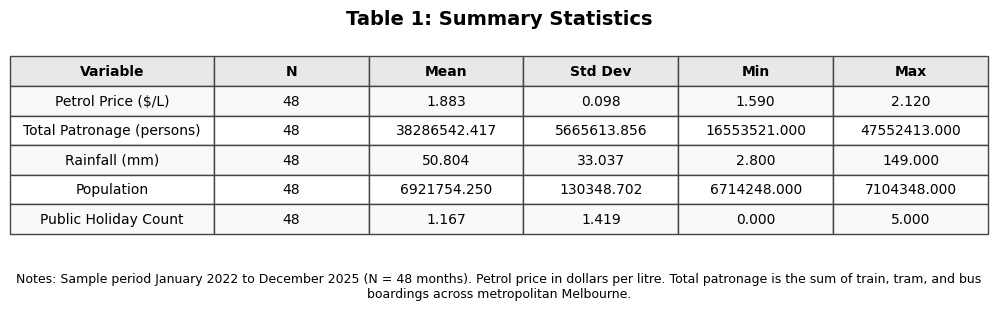

In [14]:
import os
import matplotlib.pyplot as plt

# Build a cleaner screenshot-friendly table image
styled = display_summary.copy().reset_index()
styled.rename(columns={'index': 'Variable'}, inplace=True)

num_cols = len(styled.columns)
col_widths = [0.25] + [0.19] * (num_cols - 1)
fig_width = max(10, num_cols * 1.1)
fig, ax = plt.subplots(figsize=(fig_width, 3.2))
ax.axis('off')
ax.set_title('Table 1: Summary Statistics', fontsize=14, fontweight='bold', pad=16)

header_color = ['#e8e8e8'] * num_cols

table = ax.table(
    cellText=styled.values,
    colLabels=styled.columns,
    cellLoc='center',
    loc='center',
    colColours=header_color,
    colWidths=col_widths
)

table.auto_set_font_size(False)
table.set_fontsize(10)

for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#444444')
    cell.set_height(0.15)
    if row == 0:
        cell.set_facecolor('#e8e8e8')
        cell.get_text().set_weight('bold')
    elif row % 2 == 1:
        cell.set_facecolor('#f9f9f9')
    else:
        cell.set_facecolor('#ffffff')

# Add a footnote and save both PNG and PDF for high-quality export
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
note = (
    f"Notes: Sample period January 2022 to December 2025 (N = {len(df)} months). "
    "Petrol price in dollars per litre. Total patronage is the sum of train, tram, and bus "
    "boardings across metropolitan Melbourne."
)
# Place the note below the table
fig.text(0.5, 0.06, note, ha='center', fontsize=9, wrap=True)

os.makedirs('../output', exist_ok=True)
fig.savefig('../output/table1_summary.png', dpi=220, bbox_inches='tight')
fig.savefig('../output/table1_summary.pdf', dpi=220, bbox_inches='tight')
plt.show()